# EDA — AI4I 2020 Predictive Maintenance Dataset

**Analyse exploratoire des données avant entraînement du classifieur d'état GMAO-ML.**

Dataset : `stephanmatzka/predictive-maintenance-dataset-ai4i-2020` (Kaggle) —
10 000 observations issues d'un modèle de fraiseuse, 5 capteurs + labels de défaillance.

Points analysés dans ce notebook :

1. Aperçu général et qualité (dtypes, doublons, **valeurs manquantes**) ;
2. **Déséquilibre des classes** de la cible `machine_failure` (+ modes `failure_type`) ;
3. **Distributions** des capteurs numériques (skew, formes) ;
4. Détection des **outliers** (règle IQR + boxplots par classe) ;
5. **Corrélations** entre capteurs et avec la cible ;
6. Synthèse et recommandations pour l'entraînement.

> Les figures sont également sauvegardées dans `GMAO-ML/data/reports/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda v: f"{v:.3f}")
sns.set_theme(style="whitegrid", palette="deep")

SAVE_FIGURES = True
TARGET = "machine_failure"

NUM_FEATURES = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
CAT_FEATURES = ["Type"]


def locate_project_dir() -> Path:
    """Remonte depuis le CWD jusqu'à trouver le dossier GMAO-ML/."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if candidate.name == "GMAO-ML":
            return candidate
        if (candidate / "GMAO-ML" / "data").is_dir():
            return candidate / "GMAO-ML"
        if (candidate / "data" / "ai4i_2020.csv").is_file():
            return candidate
    raise FileNotFoundError("Dossier GMAO-ML/ introuvable depuis " + str(Path.cwd()))


PROJECT_DIR = locate_project_dir()
DATA_PATH = PROJECT_DIR / "data" / "ai4i_2020.csv"
REPORTS_DIR = PROJECT_DIR / "data" / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig: plt.Figure, name: str) -> None:
    """Sauvegarde optionnelle des figures dans data/reports/."""
    if SAVE_FIGURES:
        fig.savefig(REPORTS_DIR / f"{name}.png", dpi=120, bbox_inches="tight")


print(f"Projet   : {PROJECT_DIR}")
print(f"Dataset  : {DATA_PATH}")
print(f"Rapports : {REPORTS_DIR}")

Projet   : /home/abdellah-daif/Gmao-Services-IA/GMAO-ML
Dataset  : /home/abdellah-daif/Gmao-Services-IA/GMAO-ML/data/ai4i_2020.csv
Rapports : /home/abdellah-daif/Gmao-Services-IA/GMAO-ML/data/reports


## 1. Chargement et aperçu général

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")
display(df.head(10))

Dimensions : 10000 lignes × 13 colonnes


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],machine_failure,TWF,HDF,PWF,OSF,RNF,failure_type
0,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0,No Failure
1,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0,No Failure
2,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0,No Failure
3,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0,No Failure
4,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0,No Failure
5,M,298.100,308.600,1425,41.900,11,0,0,0,0,0,0,No Failure
6,L,298.100,308.600,1558,42.400,14,0,0,0,0,0,0,No Failure
7,L,298.100,308.600,1527,40.200,16,0,0,0,0,0,0,No Failure
8,M,298.300,308.700,1667,28.600,18,0,0,0,0,0,0,No Failure
9,M,298.500,309.000,1741,28.000,21,0,0,0,0,0,0,No Failure


In [3]:
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})
print(f"Lignes entièrement dupliquées : {df.duplicated().sum()}")
summary

Lignes entièrement dupliquées : 0


,dtype,n_missing,pct_missing,n_unique
Type,object,0,0.000,3
Air temperature [K],float64,0,0.000,93
Process temperature [K],float64,0,0.000,82
Rotational speed [rpm],int64,0,0.000,941
Torque [Nm],float64,0,0.000,577
Tool wear [min],int64,0,0.000,246
machine_failure,int64,0,0.000,2
TWF,int64,0,0.000,2
HDF,int64,0,0.000,2
PWF,int64,0,0.000,2


## 2. Valeurs manquantes

On visualise le pourcentage de `NaN` par colonne — un ratio élevé (> 50 %)
rendrait une colonne inexploitable telle quelle ; un ratio faible reste
absorbable par l'imputation du pipeline (`SimpleImputer`).

[OK] Aucune valeur manquante dans ce dataset.


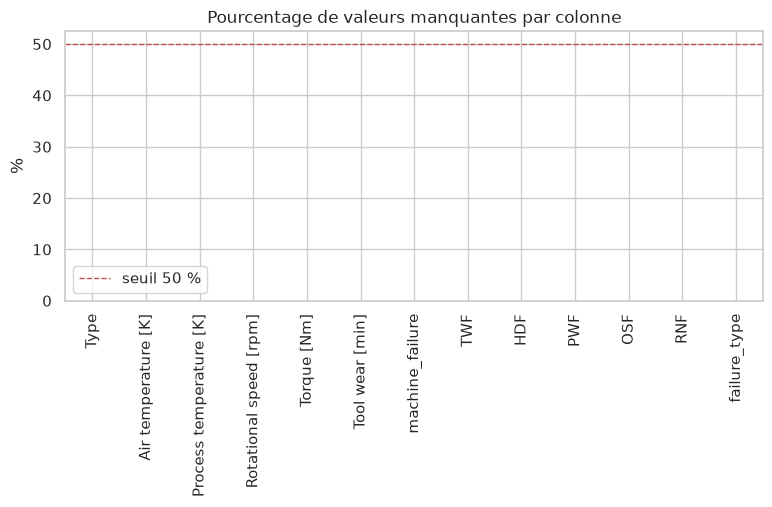

In [4]:
missing_pct = df.isna().mean() * 100

if missing_pct.sum() == 0:
    print("[OK] Aucune valeur manquante dans ce dataset.")
else:
    print(missing_pct[missing_pct > 0].sort_values(ascending=False).to_string())

fig, ax = plt.subplots(figsize=(9, 3.5))
missing_pct.plot.bar(ax=ax, color="#4C72B0")
ax.axhline(50, color="#C44E52", linestyle="--", linewidth=1, label="seuil 50 %")
ax.set_title("Pourcentage de valeurs manquantes par colonne")
ax.set_ylabel("%")
ax.legend()
save_fig(fig, "01_valeurs_manquantes")
plt.show()

## 3. Déséquilibre des classes

Point critique pour la maintenance prédictive : les défaillances sont
**rares par nature**. Un modèle naïf prédisant toujours « sain » obtient
une accuracy élevée sans jamais détecter de panne — d'où l'usage de
métriques adaptées (`f1_macro`, rappel) et de pondérations de classes.

machine_failure
0    9661
1     339

Ratio classe minoritaire : 3.39%
Baseline naïve (toujours '0') : accuracy = 96.61% mais rappel sur défaillances = 0 %


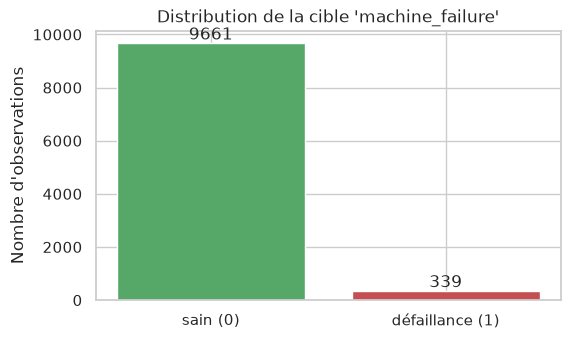

ALERTE : déséquilibre fort (3.39% < 10 %).
-> Recommandé : --balance-class-weights à l'entraînement + métriques f1_macro/rappel.


In [5]:
counts = df[TARGET].value_counts().sort_index()
minority_ratio = counts.min() / counts.sum()
naive_acc = counts.max() / counts.sum()

print(counts.to_string())
print(f"\nRatio classe minoritaire : {minority_ratio:.2%}")
print(
    f"Baseline naïve (toujours '{counts.idxmax()}') : "
    f"accuracy = {naive_acc:.2%} mais rappel sur défaillances = 0 %"
)

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(["sain (0)", "défaillance (1)"], counts.values, color=["#55A868", "#C44E52"])
ax.bar_label(bars)
ax.set_title(f"Distribution de la cible '{TARGET}'")
ax.set_ylabel("Nombre d'observations")
save_fig(fig, "02_desequilibre_cible")
plt.show()

if minority_ratio < 0.10:
    print(f"ALERTE : déséquilibre fort ({minority_ratio:.2%} < 10 %).")
    print("-> Recommandé : --balance-class-weights à l'entraînement + métriques f1_macro/rappel.")
else:
    print(f"[OK] Déséquilibre modéré ({minority_ratio:.2%}).")

### 3 bis. Modes de défaillance (`failure_type`) et effet du type produit

Chaque mode a une cause physique distincte :
`TWF` usure outil · `HDF` dissipation chaleur · `PWF` puissance (couple/vitesse)
· `OSF` usure outil sur copeaux · `RNF` aléatoire (non explicable par les capteurs).

À noter : `RNF` étant **aléatoire**, certaines lignes RNF portent
`machine_failure = 0` — c'est du bruit irréductible pour le modèle.

failure_type
No Failure           9652
HDF                   106
PWF                    80
OSF                    78
TWF                    42
Multiple Failures      24
RNF                    18


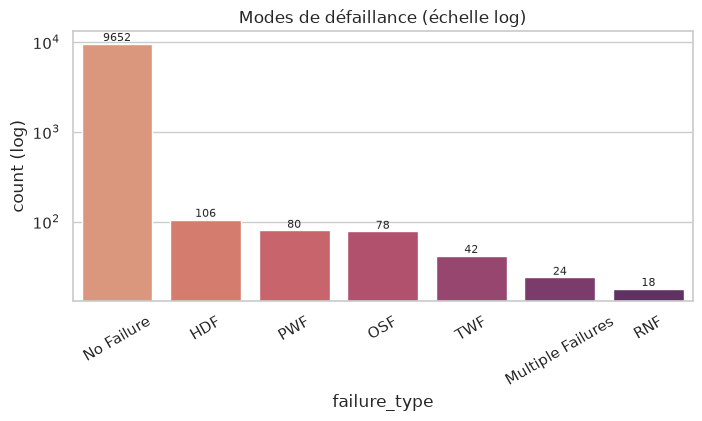

machine_failure,0,1
failure_type,,
HDF,0,106
Multiple Failures,0,24
No Failure,9643,9
OSF,0,78
PWF,0,80
RNF,18,0
TWF,0,42



Taux de défaillance par qualité produit (L < M < H) :


,n,taux_defaillance
Type,,
H,1003,2.090
L,6000,3.920
M,2997,2.770


In [6]:
ft_counts = df["failure_type"].value_counts()
print(ft_counts.to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.barplot(x=ft_counts.index, y=ft_counts.values,
            hue=ft_counts.index, palette="flare", legend=False, ax=ax)
ax.set_yscale("log")
ax.set_title("Modes de défaillance (échelle log)")
ax.set_ylabel("count (log)")
ax.tick_params(axis="x", rotation=30)
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
save_fig(fig, "03_modes_defaillance")
plt.show()

display(pd.crosstab(df["failure_type"], df[TARGET]))

type_stats = df.groupby("Type").agg(
    n=(TARGET, "size"),
    taux_defaillance=(TARGET, "mean"),
)
type_stats["taux_defaillance"] = (type_stats["taux_defaillance"] * 100).round(2)
print("\nTaux de défaillance par qualité produit (L < M < H) :")
display(type_stats)

## 4. Distributions des features numériques

In [7]:
desc = df[NUM_FEATURES].describe().T
desc["skew"] = df[NUM_FEATURES].skew()
desc

,count,mean,std,min,25%,50%,75%,max,skew
Air temperature [K],10000.000,300.005,2.000,295.300,298.300,300.100,301.500,304.500,0.114
Process temperature [K],10000.000,310.006,1.484,305.700,308.800,310.100,311.100,313.800,0.015
Rotational speed [rpm],10000.000,1538.776,179.284,1168.000,1423.000,1503.000,1612.000,2886.000,1.993
Torque [Nm],10000.000,39.987,9.969,3.800,33.200,40.100,46.800,76.600,-0.010
Tool wear [min],10000.000,107.951,63.654,0.000,53.000,108.000,162.000,253.000,0.027


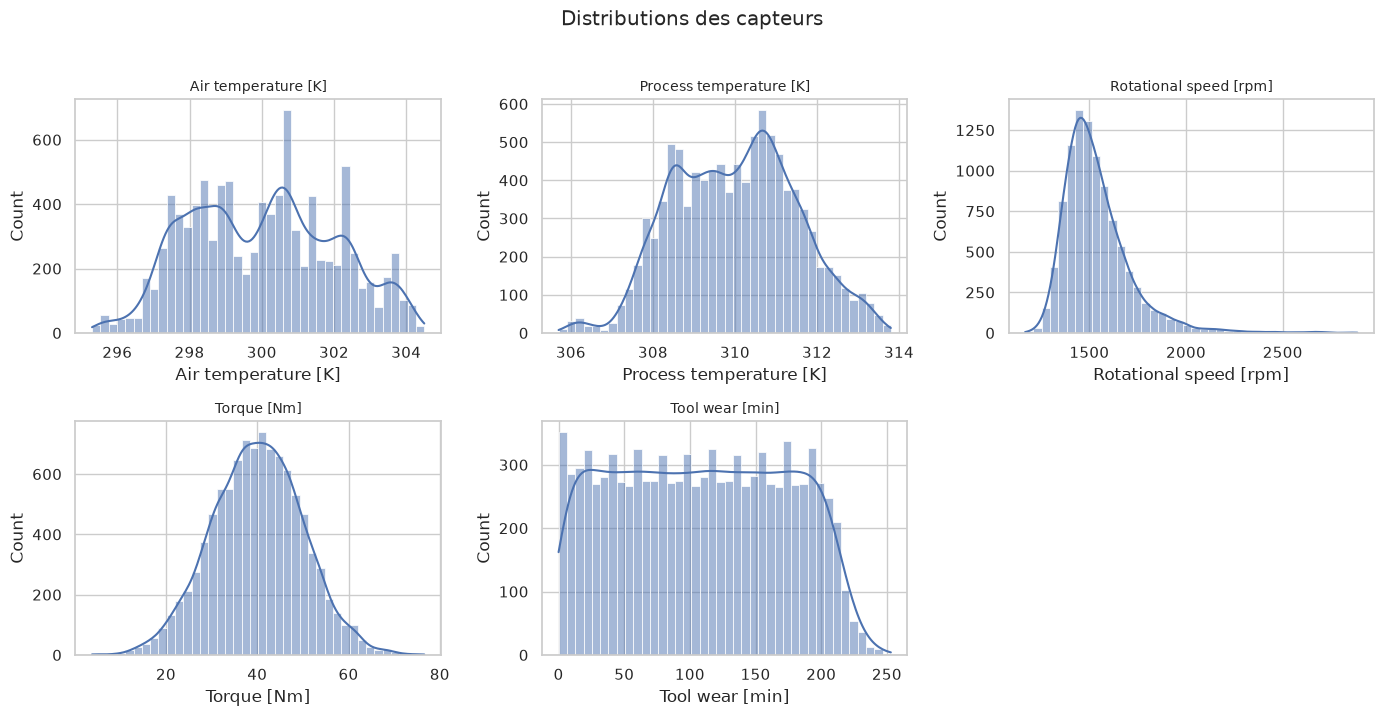

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, NUM_FEATURES):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0", bins=40)
    ax.set_title(col, fontsize=10)
axes.flat[-1].axis("off")
fig.suptitle("Distributions des capteurs", y=1.02)
fig.tight_layout()
save_fig(fig, "04_distributions_capteurs")
plt.show()

## 5. Outliers (règle IQR)

Un point est considéré atypique s'il sort de l'intervalle
`[Q1 - 1.5·IQR, Q3 + 1.5·IQR]`. On regarde ensuite si ces points
concentrent les défaillances — souvent ils en sont justement le signal.

In [9]:
rows = []
for col in NUM_FEATURES:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = ~df[col].between(low, high)
    fail_rate_in = df.loc[mask, TARGET].mean() * 100 if mask.any() else float("nan")
    rows.append({
        "feature": col,
        "borne_basse": round(low, 2),
        "borne_haute": round(high, 2),
        "n_outliers": int(mask.sum()),
        "pct_outliers": round(mask.mean() * 100, 2),
        "%_defaillances_parmi_outliers": round(fail_rate_in, 2),
    })
outliers_df = pd.DataFrame(rows).set_index("feature")
outliers_df

,borne_basse,borne_haute,n_outliers,pct_outliers,%_defaillances_parmi_outliers
feature,,,,,
Air temperature [K],293.500,306.300,0,0.000,NaN
Process temperature [K],305.350,314.550,0,0.000,NaN
Rotational speed [rpm],1139.500,1895.500,418,4.180,8.370
Torque [Nm],12.800,67.200,69,0.690,89.860
Tool wear [min],-110.500,325.500,0,0.000,NaN


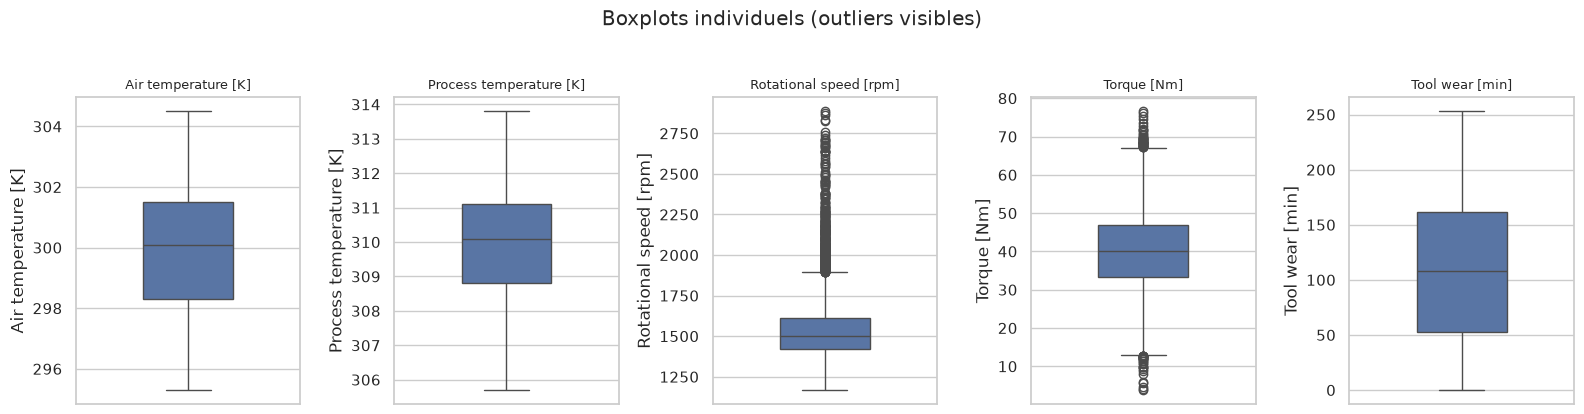

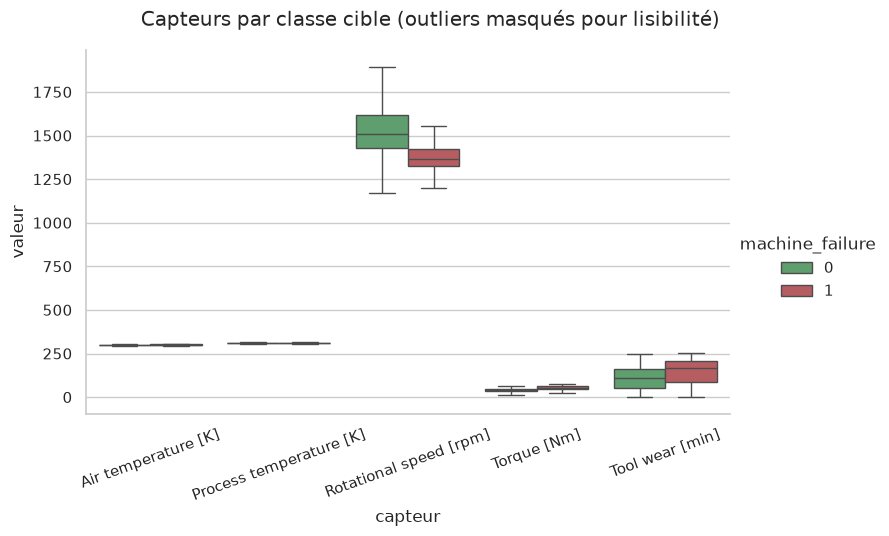

In [10]:
fig, axes = plt.subplots(1, len(NUM_FEATURES), figsize=(16, 4))
for ax, col in zip(axes, NUM_FEATURES):
    sns.boxplot(y=df[col], ax=ax, color="#4C72B0", width=0.4)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
fig.suptitle("Boxplots individuels (outliers visibles)", y=1.03)
fig.tight_layout()
save_fig(fig, "06_outliers_boxplots")
plt.show()

melted = df.melt(id_vars=[TARGET], value_vars=NUM_FEATURES,
                 var_name="capteur", value_name="valeur")
g = sns.catplot(
    data=melted, kind="box",
    x="capteur", y="valeur", hue=TARGET,
    height=4.5, aspect=1.7, showfliers=False,
    palette=["#55A868", "#C44E52"],
)
g.set_xticklabels(rotation=20)
g.fig.suptitle("Capteurs par classe cible (outliers masqués pour lisibilité)", y=1.05)
save_fig(g.fig, "07_boxplots_par_classe")
plt.show()

## 6. Corrélations

Deux attentes physiques sur ce dataset :

- `Process temperature` ≈ fortement corrélée à `Air temperature` (échauffement du procédé) ;
- `Torque` ≈ anti-corrélée à `Rotational speed` (puissance constante : P = couple × vitesse).

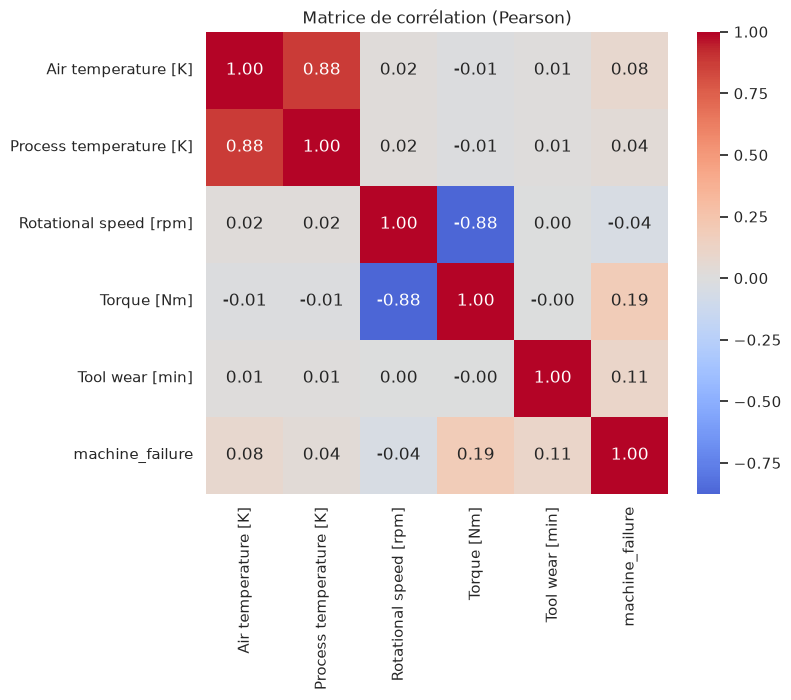

Corrélation de chaque capteur avec la cible (par |r| décroissant) :
Torque [Nm]                0.191
Tool wear [min]            0.105
Air temperature [K]        0.083
Rotational speed [rpm]    -0.044
Process temperature [K]    0.036


In [11]:
corr_cols = NUM_FEATURES + [TARGET]
corr = df[corr_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Matrice de corrélation (Pearson)")
save_fig(fig, "08_correlations")
plt.show()

print("Corrélation de chaque capteur avec la cible (par |r| décroissant) :")
print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3).to_string())

In [12]:
upper_mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = corr.where(upper_mask).stack().sort_values(key=abs, ascending=False)

strong_pairs = pairs[abs(pairs) > 0.5]
if strong_pairs.empty:
    print("[OK] Aucune paire de variables avec |r| > 0.5.")
else:
    print("Paires les plus corrélées (|r| > 0.5) :")
    print(strong_pairs.round(3).to_string())

Paires les plus corrélées (|r| > 0.5) :
Air temperature [K]     Process temperature [K]    0.876
Rotational speed [rpm]  Torque [Nm]               -0.875


## 7. Synthèse et recommandations

In [13]:
top_target_corr = (
    corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
)
n_strong_pairs = int((pairs.abs() > 0.5).sum())
total_missing_pct = float(df.isna().mean().mean() * 100)

lines = [
    "=" * 66,
    "SYNTHÈSE DE L'ANALYSE EXPLORATOIRE",
    "=" * 66,
    f"Volume                  : {df.shape[0]} lignes × {df.shape[1]} colonnes",
    f"Doublons                : {int(df.duplicated().sum())}",
    f"Valeurs manquantes      : {total_missing_pct:.2f}% en moyenne"
    + ("  -> rien à traiter" if total_missing_pct == 0 else ""),
    "",
    f"CIBLE '{TARGET}'",
    f"  Classe minoritaire    : {minority_ratio:.2%}  "
    + ("-> DESEQUILIBRE FORT (>= seuil 10%)" if minority_ratio < 0.10 else "-> acceptable"),
    f"  Baseline naive        : accuracy {naive_acc:.2%}, rappel defaillances 0%",
    f"  Capteur le plus lie   : '{top_target_corr.index[0]}' (|r|={top_target_corr.iloc[0]:.2f})",
    "",
    "RECOMMANDATIONS POUR L'ENTRAINEMENT",
    "  1. Metriques f1_macro / recall obligatoires (accuracy trompeuse ici).",
    ("  2. Activer --balance-class-weights (class_weight='balanced')." if minority_ratio < 0.10 else "  2. Pondération de classes facultative."),
    f"  3. {n_strong_pairs} paire(s) fortement corrélée(s) -> attention multicollinéarité pour la régression logistique.",
    "  4. Garder les outliers : ils concentrent les défaillances (signal, pas du bruit),",
    "     sauf RNF qui est aléatoire par construction.",
    "  5. Le preprocessing est embarqué dans le Pipeline sérialisé -> aucun risque",
    "     de divergence train/inférence.",
]
print("\n".join(lines))

SYNTHÈSE DE L'ANALYSE EXPLORATOIRE
Volume                  : 10000 lignes × 13 colonnes
Doublons                : 0
Valeurs manquantes      : 0.00% en moyenne  -> rien à traiter

CIBLE 'machine_failure'
  Classe minoritaire    : 3.39%  -> DESEQUILIBRE FORT (>= seuil 10%)
  Baseline naive        : accuracy 96.61%, rappel defaillances 0%
  Capteur le plus lie   : 'Torque [Nm]' (|r|=0.19)

RECOMMANDATIONS POUR L'ENTRAINEMENT
  1. Metriques f1_macro / recall obligatoires (accuracy trompeuse ici).
  2. Activer --balance-class-weights (class_weight='balanced').
  3. 2 paire(s) fortement corrélée(s) -> attention multicollinéarité pour la régression logistique.
  4. Garder les outliers : ils concentrent les défaillances (signal, pas du bruit),
     sauf RNF qui est aléatoire par construction.
  5. Le preprocessing est embarqué dans le Pipeline sérialisé -> aucun risque
     de divergence train/inférence.
